In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


In [3]:
ticker = "AAPL"
df = yf.download(ticker, start="2018-01-01", end="2025-01-01")
print(df.head())
print(df.tail())
print(df.columns)


[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.267086  40.276438  39.565813  39.776197  102223600
2018-01-03  40.260059  40.802379  40.196947  40.330187  118071600
2018-01-04  40.447083  40.549936  40.225013  40.332540   89738400
2018-01-05  40.907570  40.994059  40.451743  40.542909   94640000
2018-01-08  40.755630  41.050164  40.657449  40.755630   82271200
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-12-24  256.560822  256.570737  253.669277  253.868019  23234700
2024-12-26  257.375580  258.448740  255.994420  256.550862  27237100
2024-12-27  253.967392  257.057664  251.453455  256.193162  42355300
2024-12-30  250.598907  251.890657  249.158116  250.628716

In [4]:
print(df.info())
print(df.isna().sum())


<class 'pandas.DataFrame'>
DatetimeIndex: 1761 entries, 2018-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1761 non-null   float64
 1   (High, AAPL)    1761 non-null   float64
 2   (Low, AAPL)     1761 non-null   float64
 3   (Open, AAPL)    1761 non-null   float64
 4   (Volume, AAPL)  1761 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 82.5 KB
None
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [5]:
df["rolling_max_20"] = df["Close"].rolling(window=20).max()
print(df[["Close", "rolling_max_20"]].head(25))

Price           Close rolling_max_20
Ticker           AAPL               
Date                                
2018-01-02  40.267086            NaN
2018-01-03  40.260059            NaN
2018-01-04  40.447083            NaN
2018-01-05  40.907570            NaN
2018-01-08  40.755630            NaN
2018-01-09  40.750950            NaN
2018-01-10  40.741600            NaN
2018-01-11  40.973030            NaN
2018-01-12  41.396133            NaN
2018-01-16  41.185734            NaN
2018-01-17  41.865982            NaN
2018-01-18  41.903370            NaN
2018-01-19  41.716373            NaN
2018-01-22  41.375095            NaN
2018-01-23  41.384445            NaN
2018-01-24  40.725231            NaN
2018-01-25  39.998245            NaN
2018-01-26  40.091766            NaN
2018-01-29  39.261921            NaN
2018-01-30  39.030499       41.90337
2018-01-31  39.138016       41.90337
2018-02-01  39.219841       41.90337
2018-02-02  37.518089       41.90337
2018-02-05  36.580711       41.90337
2

In [6]:
df["prev_20d_high"] = df["Close"].rolling(20).max().shift(1)

In [7]:
print(df[["Close", "rolling_max_20", "prev_20d_high"]].head(25))

Price           Close rolling_max_20 prev_20d_high
Ticker           AAPL                             
Date                                              
2018-01-02  40.267086            NaN           NaN
2018-01-03  40.260059            NaN           NaN
2018-01-04  40.447083            NaN           NaN
2018-01-05  40.907570            NaN           NaN
2018-01-08  40.755630            NaN           NaN
2018-01-09  40.750950            NaN           NaN
2018-01-10  40.741600            NaN           NaN
2018-01-11  40.973030            NaN           NaN
2018-01-12  41.396133            NaN           NaN
2018-01-16  41.185734            NaN           NaN
2018-01-17  41.865982            NaN           NaN
2018-01-18  41.903370            NaN           NaN
2018-01-19  41.716373            NaN           NaN
2018-01-22  41.375095            NaN           NaN
2018-01-23  41.384445            NaN           NaN
2018-01-24  40.725231            NaN           NaN
2018-01-25  39.998245          

In [8]:
df["signal"] = (df["Close"] > df["prev_20d_high"]).astype(int)

ValueError: Operands are not aligned. Do `left, right = left.align(right, axis=1)` before operating.

In [ ]:
print(df.columns)
print(type(df["Close"]))
print(type(df["prev_20d_high"]))

MultiIndex([(         'Close', 'AAPL'),
            (          'High', 'AAPL'),
            (           'Low', 'AAPL'),
            (          'Open', 'AAPL'),
            (        'Volume', 'AAPL'),
            ('rolling_max_20',     ''),
            ( 'prev_20d_high',     '')],
           names=['Price', 'Ticker'])
<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [ ]:
df.columns = df.columns.get_level_values(0)

In [ ]:
df["rolling_max_20"] = df["Close"].rolling(20).max()
df["prev_20d_high"] = df["Close"].rolling(20).max().shift(1)
df["signal"] = (df["Close"] > df["prev_20d_high"]).astype(int)

In [ ]:
print(df["signal"].value_counts())

signal
0    1400
1     361
Name: count, dtype: int64


In [ ]:
df["fwd_5d_return"] = df["Close"].shift(-5) / df["Close"] - 1
print(df[["Close", "signal", "fwd_5d_return"]].head(30))
print(df[["Close", "signal", "fwd_5d_return"]].tail(10))

Price           Close  signal  fwd_5d_return
Date                                        
2018-01-02  40.304173       0       0.012017
2018-01-03  40.297161       0       0.011961
2018-01-04  40.484322       0       0.013004
2018-01-05  40.945248       0       0.011943
2018-01-08  40.793186       0       0.010553
2018-01-09  40.788494       0       0.027362
2018-01-10  40.779137       0       0.028516
2018-01-11  41.010784       0       0.018142
2018-01-12  41.434265       0      -0.000508
2018-01-16  41.223682       0       0.004825
2018-01-17  41.904552       0      -0.027247
2018-01-18  41.941982       0      -0.045465
2018-01-19  41.754818       0      -0.038944
2018-01-22  41.413200       0      -0.051073
2018-01-23  41.422569       0      -0.056880
2018-01-24  40.762760       0      -0.038974
2018-01-25  40.035107       0      -0.019461
2018-01-26  40.128708       0      -0.064195
2018-01-29  39.298096       0      -0.068290
2018-01-30  39.066456       0      -0.023597
2018-01-31

In [ ]:
signal_df = df[df["signal"] == 1].copy()
print(signal_df[["Close", "prev_20d_high", "signal", "fwd_5d_return"]].head())
print(signal_df[["fwd_5d_return"]].describe())

Price           Close  prev_20d_high  signal  fwd_5d_return
Date                                                       
2018-02-23  41.229664      40.640007       1       0.004046
2018-02-26  42.044861      41.229664       1      -0.012013
2018-03-09  42.282124      42.044861       1      -0.010890
2018-03-12  42.690903      42.282124       1      -0.035329
2018-04-17  41.873360      41.304832       1      -0.085839
Price  fwd_5d_return
count     359.000000
mean        0.006402
std         0.031858
min        -0.125697
25%        -0.009575
50%         0.008875
75%         0.025785
max         0.093469


In [ ]:
print(signal_df["fwd_5d_return"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

0.10   -0.032686
0.25   -0.009575
0.50    0.008875
0.75    0.025785
0.90    0.040904
Name: fwd_5d_return, dtype: float64


In [ ]:
df["fwd_5d_return"].mean()

np.float64(0.006022862017976938)

In [ ]:
df["position"] = 0

holding_period = 5
i = 0

while i < len(df):
    if df["signal"].iloc[i] == 1:
        df.iloc[i:i+holding_period, df.columns.get_loc("position")] = 1
        i += holding_period
    else:
        i += 1

In [ ]:
print(df["position"].value_counts())

position
0    1096
1     665
Name: count, dtype: int64


In [ ]:
df["daily_return"] = df["Close"].pct_change()

In [ ]:
df["strategy_return"] = df["daily_return"] * df["position"]

In [ ]:
df["equity_curve"] = (1 + df["strategy_return"]).cumprod()

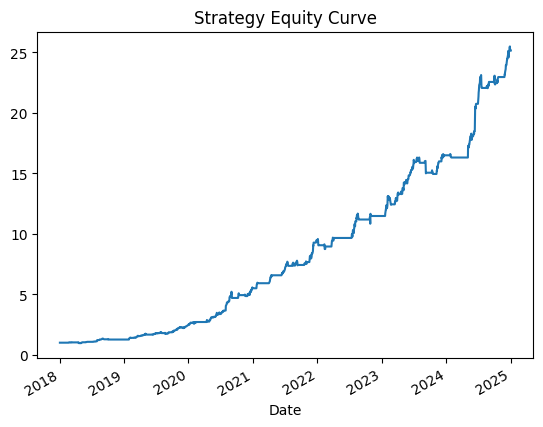

In [ ]:
df["equity_curve"].plot(title="Strategy Equity Curve")
plt.show()

In [ ]:
print(df["equity_curve"].iloc[-1])
print(df["strategy_return"].describe())

25.146872202715905
count    1760.000000
mean        0.001887
std         0.010378
min        -0.080061
25%         0.000000
50%         0.000000
75%         0.000000
max         0.104689
Name: strategy_return, dtype: float64


In [ ]:
df["running_max"] = df["equity_curve"].cummax()
df["drawdown"] = df["equity_curve"] / df["running_max"] - 1

In [ ]:
print(df["drawdown"].min())

-0.09912048556018793


In [ ]:
df["buy_hold"] = (1 + df["daily_return"]).cumprod()

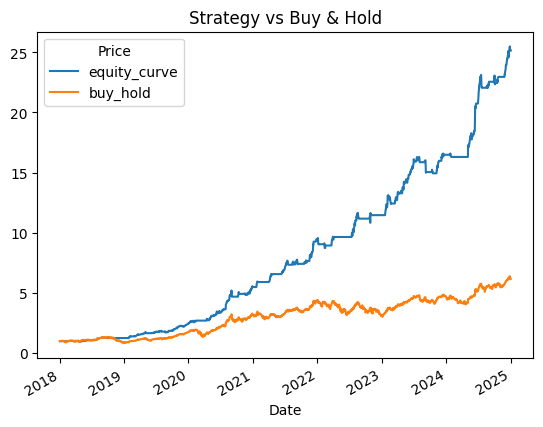

In [ ]:
df[["equity_curve", "buy_hold"]].plot(title="Strategy vs Buy & Hold")
plt.show()

In [ ]:
import random
n = 100
mp = set()
lst = []
step_lst = []
for i in range (n):
    lst.append(i+1)

for j in range (10000):
    mp = set()
    steps = 0
    while True:
        selected = random.choice(lst)
        mp.add(selected)
        steps += 1
        if len(mp) == n:
            step_lst.append(steps)
            break
analytical = n * sum(1/k for k in range(1, n+1))
print(f"Simulated: {sum(step_lst)/len(step_lst):.3f}, Analytical: {analytical:.3f}")



Simulated: 521.014, Analytical: 518.738


In [ ]:
import numpy as np

def simulate_coupon(n, simulations=10000):
    draws = np.random.randint(0, n, size=(simulations, n*15))
    total = 0
    for sim in draws:
        seen = set()
        for d in sim:
            seen.add(d)
            total += 1
            if len(seen) == n:
                break
    return total / simulations

print(f"Simulated: {simulate_coupon(100):.3f}")

Simulated: 517.206


In [ ]:
import numpy as np
A = np.array([
    [-0.5,0.375,0.375,0.125,0.125],
    [0.125,-1,0.375,0,0],
    [0.125,0.125,-1,0,0],
    [0.125,0,0.25,-0.125,0],
    [1,1,1,1,1],
    ])
b = np.array([0,0,0,0,1])

pi = np.linalg.solve(A,b)
ex = 1/pi
print (pi, ex)

[0.23018868 0.04150943 0.03396226 0.29811321 0.39622642] [ 4.3442623  24.09090909 29.44444444  3.35443038  2.52380952]


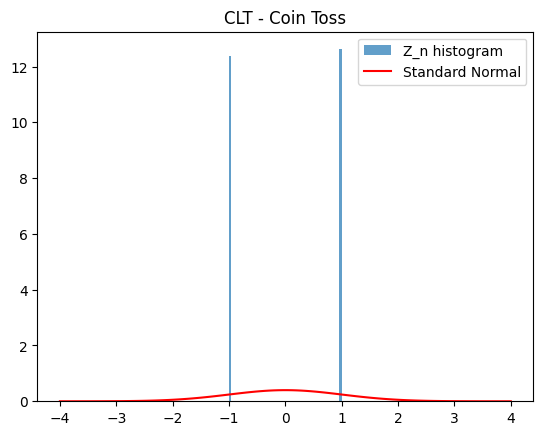

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parameters
n = 50  # coin tosses per experiment
num_experiments = 10000  # how many times we repeat
mu = 0.5
sigma = 0.5

# Storage
Zn_values = []

# Run experiments
for _ in range(num_experiments):
    samples = np.random.binomial(1, 0.5, n)
    Sn = np.sum(samples)
    Zn = (Sn - n*mu) / (sigma * np.sqrt(n))
    Zn_values.append(Zn)

# Plot
plt.hist(Zn_values, bins=50, density=True, alpha=0.7, label='Z_n histogram')

# Overlay standard normal
x = np.linspace(-4, 4, 100)
plt.plot(x, stats.norm.pdf(x), 'r-', label='Standard Normal')

plt.legend()
plt.title('CLT - Coin Toss')
plt.show()


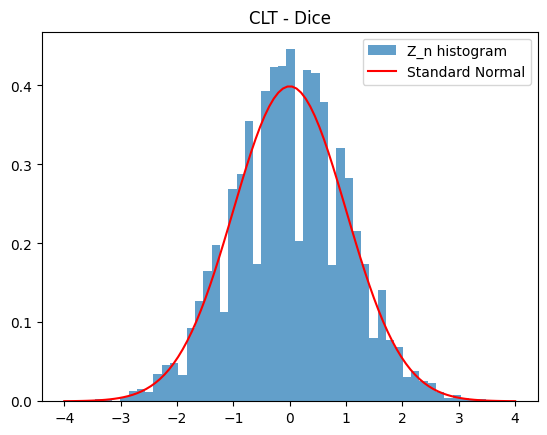

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parameters
n = 50  # dice per experiment
num_experiments = 10000  # how many times we repeat
mu = 3.5
sigma = 1.708

# Storage
Zn_values = []

# Run experiments
for _ in range(num_experiments):
    samples = np.random.randint(1, 7, n)
    Sn = np.sum(samples)
    Zn = (Sn - n*mu) / (sigma * np.sqrt(n))
    Zn_values.append(Zn)

# Plot
plt.hist(Zn_values, bins=50, density=True, alpha=0.7, label='Z_n histogram')

# Overlay standard normal
x = np.linspace(-4, 4, 100)
plt.plot(x, stats.norm.pdf(x), 'r-', label='Standard Normal')

plt.legend()
plt.title('CLT - Dice')
plt.show()

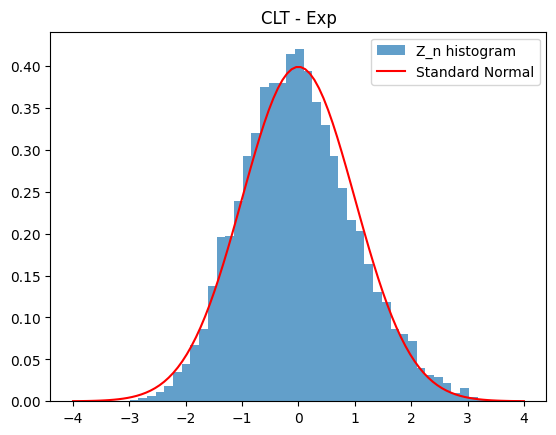

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parameters
n = 50  # exponent experiment
num_experiments = 10000  # how many times we repeat
mu = 1
sigma = 1

# Storage
Zn_values = []

# Run experiments
for _ in range(num_experiments):
    samples = np.random.exponential(1, n)
    Sn = np.sum(samples)
    Zn = (Sn - n*mu) / (sigma * np.sqrt(n))
    Zn_values.append(Zn)

# Plot
plt.hist(Zn_values, bins=50, density=True, alpha=0.7, label='Z_n histogram')

# Overlay standard normal
x = np.linspace(-4, 4, 100)
plt.plot(x, stats.norm.pdf(x), 'r-', label='Standard Normal')

plt.legend()
plt.title('CLT - Exp')
plt.show()

In [ ]:
import random
import numpy as np
def sam_mean(n):
    count = 0
    width = []
    for i in range(1000):
        samples = np.random.normal(5, 2, n)
        sam_mean = np.mean(samples)
        upper_bound = sam_mean  + 1.96 * 2 / n**0.5
        lower_bound = sam_mean  - 1.96 * 2 / n**0.5
        if lower_bound <= 5 <= upper_bound:
            count+=1
        width.append(upper_bound - lower_bound)
    avg_width = np.mean(width)
    return count/1000, avg_width

print (sam_mean(3))
print (sam_mean(5))
print (sam_mean(1000))



(0.946, np.float64(4.526426110446665))
(0.958, np.float64(3.506154588719669))
(0.952, np.float64(0.2479225685572004))


In [ ]:
import numpy as np

prices = np.array([100, 101, 103, 102, 105])

print(prices)
print(prices.dtype)
print(prices.shape)

[100 101 103 102 105]
int64
(5,)


In [ ]:
prices_2d = np.array([[100, 101, 103],
                       [102, 105, 107]])

print(prices_2d.shape)
print(prices_2d.dtype)

(2, 3)
int64


In [ ]:
prices = np.array([100, 101, 103, 102, 105])

print(prices + 1)
print(prices * 2)
print(prices - prices[0])

[101 102 104 103 106]
[200 202 206 204 210]
[0 1 3 2 5]


In [ ]:
prices = np.array([100, 102, 101, 105, 110, 108])

returns = (prices[1:] - prices[:-1]) / prices[:-1]

print(returns)

[ 0.02       -0.00980392  0.03960396  0.04761905 -0.01818182]


In [ ]:
way1 = (prices[-1] - prices[0]) / prices[0]
way2 = np.prod(1 + returns) - 1

print(way1)
print(way2)

0.08
0.08000000000000007


In [ ]:
returns = np.array([0.02, -0.009, 0.039, 0.047, -0.018])

positive = returns[returns < -0.01]
print(positive)
print(returns > 0)

[-0.018]
[ True False  True  True False]


In [ ]:
prices = np.array([200, 210, 205, 220, 215, 230, 225])
returns = (prices[1:]-prices[:-1])/prices[:-1]
positive = returns[returns > 0]
comp_return = np.prod(returns + 1)-1
print(positive)
print(comp_return)

[0.05       0.07317073 0.06976744]
0.125


In [ ]:
rng = np.random.default_rng(seed=42)

simulated_returns = rng.normal(loc=0.001, scale=0.02, size=1000000)

print(simulated_returns.shape)
print(simulated_returns.mean())
print(simulated_returns.std())

(1000000,)
0.0010019500499578757
0.02000965286480637


Shape: (253,)
Start price (approx): 100.0
End price: 120.7104339649378
Min: 98.7039085142547
Max: 124.9346588955875


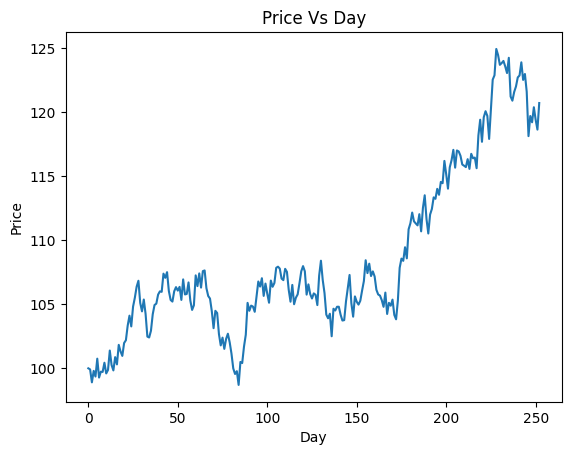

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=70)

# Simulate 252 daily returns (roughly 1 trading year)
# Mean ~0, std ~1% per day — modest but realistic
daily_returns = rng.normal(loc=0.0, scale=0.01, size=252)

# Gross returns: 1 + r converts a return into a growth multiplier
gross_returns = 1 + daily_returns

# Starting price
P0 = 100.0

# Price path
price_path = np.concatenate([[P0], P0 * np.cumprod(gross_returns)])
day = np.arange(253)

returns = (price_path[1:]-price_path[:-1])/price_path[:-1]
log_returns = np.log(price_path[1:]/price_path[:-1])

print("Shape:", price_path.shape)
print("Start price (approx):", price_path[0])
print("End price:", price_path[-1])
print("Min:", price_path.min())
print("Max:", price_path.max())

plt.plot(day, price_path)
plt.xlabel("Day")
plt.ylabel("Price")
plt.title("Price Vs Day")
plt.show()



98.78547900028227


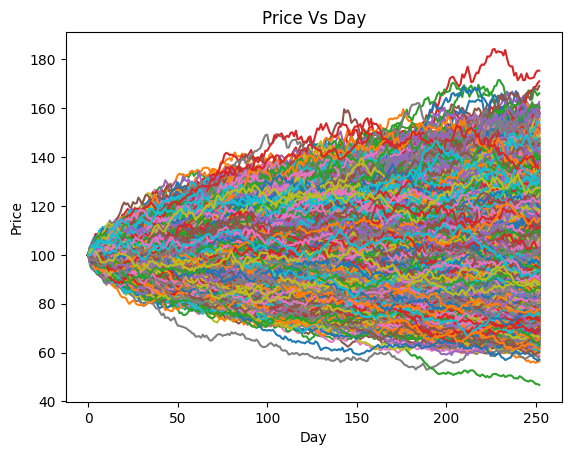

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=70)
returns = np.zeros((10000,252))

for i in range (10000):
    returns[i] = rng.normal(loc=0 , scale= 0.01, size= 252)

PO= 100
price_path = np.zeros((10000,253))
for i in range(10000):
    price_path[i] = np.concatenate([[PO] , PO * np.cumprod(returns[i]+1)])
day = np.arange(253)
print(np.median(price_path[:,-1]))
for i in range(10000):
    plt.plot(day, price_path[i])
plt.xlabel("Day")
plt.ylabel("Price")
plt.title("Price Vs Day")
plt.show()

In [ ]:
#mean price on each day
mean_day = np.mean(price_path, axis = 0)[-1]

#median of terminal price
median_day = np.median(price_path, axis = 0)[-1]

#standard deviation of terminal price
std_day = np.std(price_path, axis = 0)[-1]

print(f"Mean = {mean_day}, Median = {median_day}, Std = {std_day}")


Mean = 100.02387053775735, Median = 98.78547900028227, Std = 15.943554411696276


In [ ]:
below_90 = (price_path<90).any(axis = 1)
first_90 = (price_path[below_90]<90).argmax(axis=1)


global_mean = price_path.mean()

global_mean_demeaner = price_path - global_mean


day_mean = price_path.mean(0).reshape((1,253))
day_mean_demeaner = price_path - day_mean

path_mean = price_path.mean(1).reshape((-1,1))
path_mean_demeaner = price_path - path_mean

normal_path = price_path/price_path[:,[0]]
print (price_path[:,[0]].shape)

(10000,)


In [ ]:
import pandas as pd
import numpy as np

# Two price series — different lengths
prices_a = [100, 101, 102, 103, 104]
prices_b = [200, 202, 204, 206]

a = pd.Series(prices_a)
b = pd.Series(prices_b)

c = np.array(prices_a)
d = np.array(prices_b)

print(a)
print("---")
print(b)
print("---")
print(a + b)

0    100
1    101
2    102
3    103
4    104
dtype: int64
---
0    200
1    202
2    204
3    206
dtype: int64
---
0    300.0
1    303.0
2    306.0
3    309.0
4      NaN
dtype: float64


In [ ]:
# What happens when indices don't match at all?
x = pd.Series([10, 20, 30], index=[0, 1, 2])
y = pd.Series([10, 20, 30], index=[1, 2, 3])

print(x + y)

0     NaN
1    30.0
2    50.0
3     NaN
dtype: float64


In [ ]:
# Now a trading-relevant example
import pandas as pd

nifty = pd.Series([17000, 17100, 17200, 17300],
                  index=['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04'])

sensex = pd.Series([71000, 71500, 72000],
                   index=['2024-01-01', '2024-01-02', '2024-01-04'])

print(nifty + sensex)

2024-01-01    88000.0
2024-01-02    88600.0
2024-01-03        NaN
2024-01-04    89300.0
dtype: float64


In [ ]:
data = {
    'close': [17000, 17100, 17200, 17300],
    'volume': [150000, 180000, 120000, 200000],
    'returns': [None, 0.0059, 0.0058, 0.0058]
}

dates = ['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04']

df = pd.DataFrame(data, index=dates)
print(df)
print("---")
print(df.dtypes)
print("---")
print(df.shape)

            close  volume  returns
2024-01-01  17000  150000      NaN
2024-01-02  17100  180000   0.0059
2024-01-03  17200  120000   0.0058
2024-01-04  17300  200000   0.0058
---
close        int64
volume       int64
returns    float64
dtype: object
---
(4, 3)


In [ ]:
# 1. Select a single column
print(df['close'])
print(type(df['close']))

2024-01-01    17000
2024-01-02    17100
2024-01-03    17200
2024-01-04    17300
Name: close, dtype: int64
<class 'pandas.Series'>


In [ ]:
# 2. Select multiple columns
print(df[['close', 'volume']])
print(type(df[['close', 'volume']]))

            close  volume
2024-01-01  17000  150000
2024-01-02  17100  180000
2024-01-03  17200  120000
2024-01-04  17300  200000
<class 'pandas.DataFrame'>


In [ ]:
# 3. Select a single row by label
print(df.loc['2024-01-02'])

close       17100.0000
volume     180000.0000
returns         0.0059
Name: 2024-01-02, dtype: float64


In [ ]:
# 4. Select a single row by position
print(df.iloc[1])

close       17100.0000
volume     180000.0000
returns         0.0059
Name: 2024-01-02, dtype: float64


In [ ]:
# 1. Compute daily returns from close prices
df['daily_return'] = df['close'].pct_change()
print(df)

            close  volume  returns  daily_return
2024-01-01  17000  150000      NaN           NaN
2024-01-02  17100  180000   0.0059      0.005882
2024-01-03  17200  120000   0.0058      0.005848
2024-01-04  17300  200000   0.0058      0.005814


In [ ]:
# 2. Boolean filtering — days where volume was above 160000
high_volume = df[df['volume'] > 160000]
print(high_volume)

            close  volume  returns  daily_return
2024-01-02  17100  180000   0.0059      0.005882
2024-01-04  17300  200000   0.0058      0.005814


In [ ]:
# 3. Simple summary stats
print(df['close'].describe())

count        4.000000
mean     17150.000000
std        129.099445
min      17000.000000
25%      17075.000000
50%      17150.000000
75%      17225.000000
max      17300.000000
Name: close, dtype: float64


In [ ]:
df['price_range'] = df['close'] - df['close'].min()
high_returns = df[df['daily_return']>0.00585]
high_volume_mean = high_volume['volume'].mean()

print(df)
print("=====")
print(high_returns)
print("=====")
print(high_volume_mean)
print("=====")

            close  volume  returns  daily_return  price_range
2024-01-01  17000  150000      NaN           NaN            0
2024-01-02  17100  180000   0.0059      0.005882          100
2024-01-03  17200  120000   0.0058      0.005848          200
2024-01-04  17300  200000   0.0058      0.005814          300
=====
            close  volume  returns  daily_return  price_range
2024-01-02  17100  180000   0.0059      0.005882          100
=====
190000.0
=====


In [ ]:
print(df.isnull().sum())
print("---")
df_filled = df.ffill()
print(df_filled)
print("---")
df_dropped = df.dropna()
print(df_dropped)

close           0
volume          0
returns         1
daily_return    1
price_range     0
dtype: int64
---
            close  volume  returns  daily_return  price_range
2024-01-01  17000  150000      NaN           NaN            0
2024-01-02  17100  180000   0.0059      0.005882          100
2024-01-03  17200  120000   0.0058      0.005848          200
2024-01-04  17300  200000   0.0058      0.005814          300
---
            close  volume  returns  daily_return  price_range
2024-01-02  17100  180000   0.0059      0.005882          100
2024-01-03  17200  120000   0.0058      0.005848          200
2024-01-04  17300  200000   0.0058      0.005814          300


In [ ]:
import pandas as pd

closing = {
    "Close": [17000, 17100, 17200, 17300]
}

dates = ['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04']

df = pd.DataFrame(closing, index=dates)
df['daily_return'] = df['Close'].pct_change()
df['above_mean'] = df['Close']>df['Close'].mean()

above_mean_df = df[df['above_mean']==True]
above_mean_df['daily_return'].mean()

print (df)
print ("======")
print (above_mean_df)
print ("======")
print (above_mean_df['daily_return'].mean())


            Close  daily_return  above_mean
2024-01-01  17000           NaN       False
2024-01-02  17100      0.005882       False
2024-01-03  17200      0.005848        True
2024-01-04  17300      0.005814        True
            Close  daily_return  above_mean
2024-01-03  17200      0.005848        True
2024-01-04  17300      0.005814        True
0.005830953352373158


In [ ]:
obj = pd.Series([4,7,-5,3])
obj

0    4
1    7
2   -5
3    3
dtype: int64

In [ ]:
populations = {"Ohio": {2000: 1.5, 2001: 1.7, 2002: 3.6},
               "Nevada": {2003: 2.4, 2004: 2.9}}

frame = pd.DataFrame(populations)

pdata = {'Ohio':frame['Ohio'][:],
         'Nevada':frame['Nevada'][:]
}

frame2 = pd.DataFrame(pdata)

frame2

,Ohio,Nevada
2000,1.5,NaN
2001,1.7,NaN
2002,3.6,NaN
2003,NaN,2.4
2004,NaN,2.9


In [ ]:
import numpy as np
frame = pd.DataFrame(np.arange(12.).reshape((4, 3)), columns=list("bde"),
                      index=["Utah", "Ohio", "Texas", "Oregon"])


          b     d     e
Utah    0.0   1.0   2.0
Ohio    3.0   4.0   5.0
Texas   6.0   7.0   8.0
Oregon  9.0  10.0  11.0
Texas    7.0
Name: d, dtype: float64


Utah      0.0
Ohio      3.0
Texas     6.0
Oregon    9.0
Name: b, dtype: float64

In [ ]:
obj = pd.Series([7, -5, 7, 4, 2, 0, 4,4,5])
obj.rank()

0    8.5
1    1.0
2    8.5
3    5.0
4    3.0
5    2.0
6    5.0
7    5.0
8    7.0
dtype: float64

In [ ]:
import pandas as pd
import numpy as np
no_stocks = 5
no_days = 6
stock_price = np.random.normal(loc=200, scale=20, size=(no_stocks,no_days))
df = pd.DataFrame(stock_price, columns=[f'day_{i+1}' for i in range(no_days)], index=[f'stock_{i+1}' for i in range(no_stocks)])
df_return = df.pct_change(axis=1)
high_returns = df_return[df_return>0.02].ffill(axis=1)
print(df_return.describe())
print(df_return)
print(high_returns)

       day_1     day_2     day_3     day_4     day_5     day_6
count    0.0  5.000000  5.000000  5.000000  5.000000  5.000000
mean     NaN  0.011264 -0.010651 -0.088242  0.136308 -0.080876
std      NaN  0.130542  0.120056  0.177398  0.326597  0.142885
min      NaN -0.177183 -0.146282 -0.346109 -0.130639 -0.202914
25%      NaN -0.074558 -0.049080 -0.132610 -0.001990 -0.162554
50%      NaN  0.090793 -0.039006 -0.055109  0.040693 -0.101562
75%      NaN  0.108102 -0.000246 -0.053967  0.069167 -0.100001
max      NaN  0.109167  0.181362  0.146586  0.704310  0.162652
         day_1     day_2     day_3     day_4     day_5     day_6
stock_1    NaN  0.108102 -0.146282 -0.055109 -0.001990 -0.101562
stock_2    NaN  0.109167 -0.049080 -0.053967  0.040693 -0.202914
stock_3    NaN -0.074558 -0.039006  0.146586  0.069167 -0.162554
stock_4    NaN  0.090793 -0.000246 -0.346109  0.704310 -0.100001
stock_5    NaN -0.177183  0.181362 -0.132610 -0.130639  0.162652
         day_1     day_2     day_3     day_

In [ ]:
stock_price = np.random.normal(loc=150, scale=15, size=(10,4))
df = pd.DataFrame(stock_price, columns=[f"Stock_{i+1}" for i in range(4)], index=[f"Day_{i+1}" for i in range(10)])
df.iloc[2,3] = np.nan
df_filled = df.ffill()
df_return = df_filled.pct_change()
high_returns = df_return[(df_return>0).all(axis=1)]
print(df)
print("===========")
print(df_return)
print("===========")
print(high_returns)


           Stock_1     Stock_2     Stock_3     Stock_4
Day_1   153.899555  128.775912  152.779814  149.284171
Day_2   150.493894  145.410095  123.128472  141.729919
Day_3   153.202521  153.234214  148.940226         NaN
Day_4   155.838132  157.824395  141.175673  155.120913
Day_5   161.682041  142.398436  147.457842  159.334846
Day_6   153.694419  170.623103  144.281602  180.001147
Day_7   165.898202  178.661138  157.941489  148.618103
Day_8   127.826231  127.542218  136.671255  158.831195
Day_9   138.497525  151.257527  156.084720  150.495827
Day_10  160.610993  163.766993  169.904815  179.536502
         Stock_1   Stock_2   Stock_3   Stock_4
Day_1        NaN       NaN       NaN       NaN
Day_2  -0.022129  0.129172 -0.194079 -0.050603
Day_3   0.017998  0.053807  0.209633  0.000000
Day_4   0.017203  0.029955 -0.052132  0.094482
Day_5   0.037500 -0.097741  0.044499  0.027165
Day_6  -0.049403  0.198209 -0.021540  0.129704
Day_7   0.079403  0.047110  0.094675 -0.174349
Day_8  -0.229490 -0

In [ ]:
stock_price = np.random.normal(loc=200, scale = 15, size=(20,3))
stock_volume = np.random.randint(low=100000, high=500000, size=(20,3))
df_price = pd.DataFrame(stock_price, columns=[f"Stock_{i+1}" for i in range(3)], index= [f"Day_{i+1}" for i in range(20)])
df_volume = pd.DataFrame(stock_volume, columns=[f"Volume_{i+1}" for i in range(3)], index= [f"Day_{i+1}" for i in range(20)])
df_price.iloc[13,1] = np.nan
df_price.iloc[10,0] = np.nan
df_price_filled = df_price.ffill()
df_return = df_price_filled.pct_change()
low_return_day = df_return[(df_return<-0.05).any(axis=1)]
df_ret_vol = pd.merge(left=df_return,right=df_volume, left_index=True, right_index=True)
pos_ret = df_ret_vol[(df_ret_vol['Stock_1']>0) & (df_ret_vol['Volume_1']>df_ret_vol['Volume_1'].mean())]
print(df_ret_vol)
print(df_return.describe())
print(pos_ret)


         Stock_1   Stock_2   Stock_3  Volume_1  Volume_2  Volume_3
Day_1        NaN       NaN       NaN    189245    322523    453005
Day_2  -0.019904 -0.059695 -0.116384    486087    182368    296841
Day_3   0.042805  0.012033  0.040061    456644    131964    124656
Day_4  -0.052872  0.040815 -0.149476    296524    246873    498201
Day_5  -0.038518  0.021572  0.207757    123824    196973    277262
Day_6   0.078568  0.005617 -0.002381    433683    217514    276118
Day_7  -0.043358 -0.167043 -0.022633    253262    443187    275774
Day_8   0.006340  0.122390 -0.088280    245689    415690    313122
Day_9  -0.028576 -0.068460  0.098914    316195    253482    344928
Day_10  0.012079  0.076757 -0.162298    475977    151775    322925
Day_11  0.000000  0.089318  0.425590    150137    460115    347938
Day_12  0.043784 -0.033064 -0.127232    495118    402592    468485
Day_13  0.048417  0.031508 -0.092084    218202    150693    214891
Day_14 -0.164614  0.000000  0.092971    210094    211568    42

In [ ]:
vol = df_ret_vol['Stock_1'].groupby([df_ret_vol['Volume_1'],df_ret_vol['Volume_2'] ]).size()
vol.


Volume_2,105982,131964,135791,143023,150693,151775,182368,196973,211568,217514,246873,253482,272519,273209,322523,402592,415690,443187,453359,460115
Volume_1,,,,,,,,,,,,,,,,,,,,
123824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
189245,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
210094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
215266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
218202,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222418,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
253262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


In [ ]:
people = pd.DataFrame(np.random.standard_normal((5,5)), columns=["a", "b", "c", "d", "e"],index=["Joe", "Steve", "Wanda", "Jill", "Trey"])
mapping = {"a": "red", "b": "red", "c": "blue","d": "blue", "e": "red", "f" : "orange"}
print(people.T.groupby(mapping).count().T)
print(people.groupby(len).sum())

       blue  red
Joe       2    3
Steve     2    3
Wanda     2    3
Jill      2    3
Trey      2    3
          a         b         c         d         e
3 -1.356052  2.065927  0.177703  0.697308  1.491687
4  1.516338 -0.664200 -0.250341  4.035879  0.130185
5 -0.479726  1.568512 -1.111088 -1.353340 -1.910373


In [ ]:
ind = pd.MultiIndex.from_arrays([["US", "US", "US", "JP", "JP"],[1, 3, 5, 1, 3]], names=["city", "tenor"])
heir_df = pd.DataFrame(np.random.standard_normal((5,4)), index=ind)
print(heir_df)
heir_df.groupby(level="city").mean()

                   0         1         2         3
city tenor                                        
US   1     -1.244320 -2.223738 -0.728577  0.738260
     3      0.387683  0.098064  1.504029 -0.488089
     5     -0.816859  0.025627  0.135095  0.785023
JP   1     -0.445439 -0.341929 -0.173557 -1.072025
     3     -2.042909  0.385829  0.015106  1.151365


,0,1,2,3
city,,,,
JP,-1.244174,0.021950,-0.079225,0.039670
US,-0.557832,-0.700016,0.303516,0.345065


In [ ]:
suits = ["H", "S", "C", "D"] 
card_val = (list(range(1, 11)) + [10] * 3) * 4
base_names = ["A"] + list(range(2,11)) + ["J", "Q", "K"]
cards = []
for suit in suits:
    for name in base_names:
        cards.append(str(name)+suit)
deck = pd.Series(card_val, index=cards)
def draw(deck, n=5):
    return deck.sample(n)
def get_suit(card):
    return card[-1]
deck

<bound method Series.sum of 6D    6
AS    1
9C    9
8S    8
5D    5
dtype: int64>

In [ ]:

df = pd.DataFrame({"category": ["a", "a", "a", "a","b", "b", "b", "b"],
                   "data": np.random.standard_normal(8),
                   "weights": np.random.uniform(size=8)})
grouped = df.groupby("category")
def get_wavg(group):
    return np.average(group["data"], weights=group["weights"])
grouped.apply(get_wavg)

category
a   -0.741291
b    0.517011
dtype: float64

In [ ]:
daily_returns = pd.DataFrame(np.random.normal(loc=0, scale=0.1, size=(20,4)),
                             columns=[f"Stock_{i+1}" for i in range(4)],
                             index=[f"Day_{i+1}" for i in range(20)])
Volume = pd.DataFrame(np.random.randint(low=1000, high=5000, size=(20,1)),columns=["volume"],
                      index=[f"Day_{i+1}" for i in range(20)])
# df = pd.merge(daily_returns, Volume, left_index= True, right_index=True )
df["volume"] = Volume 
# df["market"] = df.groupby()
df

,Stock_4,Stock_5,Stock_6,Stock_7,volume,market
Day_1,-0.001451,0.062591,-0.196146,0.090418,3271,True
Day_2,-0.026559,-0.001855,0.093034,-0.104925,1561,True
Day_3,-0.084325,-0.056664,0.099980,0.070498,2892,True
Day_4,-0.055048,0.009872,-0.087096,0.011780,3492,True
Day_5,-0.077382,-0.035070,-0.046973,0.124494,2243,True
Day_6,-0.142414,0.000317,-0.010712,-0.062515,2942,True
Day_7,-0.174094,0.051693,0.132485,0.169050,4458,True
Day_8,0.031333,0.126275,-0.045314,0.038575,1845,True
Day_9,0.054945,0.079574,0.258324,-0.022940,2289,True
Day_10,-0.069377,0.079113,-0.184171,-0.051628,3727,True


In [ ]:
import numpy as np
daily_returns = pd.DataFrame(np.random.normal(loc=0, scale=0.1, size=(20,3)),
                             columns=[f"Stock_{i+1}" for i in range(3)],
                             index=[f"Day_{i+1}" for i in range(20)])
volume = pd.DataFrame(np.random.randint(low= 1000, high= 5000, size=(20,1)), 
                      index=[f"Day_{i+1}" for i in range(20)])

daily_returns["volume"] = volume

daily_returns["above_mean"] = daily_returns["volume"].mean()<daily_returns["volume"]

grouped = daily_returns.groupby(daily_returns["above_mean"]).mean()

grouped.drop(columns="volume")


,Stock_1,Stock_2,Stock_3
above_mean,,,
False,0.031109,-0.018538,0.038303
True,0.000684,-0.021740,0.023355


In [ ]:
pd.date_range("2026-01-01", "2026-12-31", freq= "BMS")


DatetimeIndex(['2026-01-01', '2026-02-02', '2026-03-02', '2026-04-01',
               '2026-05-01', '2026-06-01', '2026-07-01', '2026-08-03',
               '2026-09-01', '2026-10-01', '2026-11-02', '2026-12-01'],
              dtype='datetime64[us]', freq='BMS')

In [ ]:
stamp = pd.Timestamp("2026-05-03 18:56")
stamp_nz = stamp.tz_localize("Pacific/Auckland")
stamp_in = stamp_nz.tz_convert("Asia/Kolkata")
stamp_in


Timestamp('2026-05-03 12:26:00+0530', tz='Asia/Kolkata')

In [ ]:
import numpy as np
date_range = pd.date_range("2023-01-01","2023-12-31", freq="B")
price_series = pd.DataFrame(np.random.normal(loc=0, scale=0.01, size=(len(date_range), 1)), index= date_range, columns= ["daily_return"])
price_series["price"] = ((price_series["daily_return"]+1).cumprod())*18000
price_monthly = price_series.resample("BME", label="right", closed="right").last()
price_monthly["monthly_return"] = price_monthly["price"]/price_monthly["price"].shift(1) - 1
price_monthly.loc["2023-01-31","monthly_return"] = price_monthly.loc["2023-01-31","price"]/18000 - 1
price_monthly["cum_return"] = (price_monthly["monthly_return"]+1).cumprod()
price_monthly

,daily_return,price,monthly_return,cum_return
2023-01-31,0.002873,17064.588471,-0.051967,0.948033
2023-02-28,0.008262,16555.029363,-0.029861,0.919724
2023-03-31,0.002351,16011.021207,-0.032861,0.889501
2023-04-28,0.009466,16455.591045,0.027766,0.914200
2023-05-31,0.012034,16661.326860,0.012502,0.925629
2023-06-30,0.002577,17129.361722,0.028091,0.951631
2023-07-31,-0.016786,16105.070149,-0.059797,0.894726
2023-08-31,-0.007376,15805.729184,-0.018587,0.878096
2023-09-29,0.000638,15827.201951,0.001359,0.879289
2023-10-31,-0.005359,16342.413260,0.032552,0.907912


In [ ]:
price_daily = price_monthly.reindex(index=date_range).ffill()
print(price_daily[:10])
print(price_daily[-10:])

            daily_return  price  monthly_return  cum_return
2023-01-02           NaN    NaN             NaN         NaN
2023-01-03           NaN    NaN             NaN         NaN
2023-01-04           NaN    NaN             NaN         NaN
2023-01-05           NaN    NaN             NaN         NaN
2023-01-06           NaN    NaN             NaN         NaN
2023-01-09           NaN    NaN             NaN         NaN
2023-01-10           NaN    NaN             NaN         NaN
2023-01-11           NaN    NaN             NaN         NaN
2023-01-12           NaN    NaN             NaN         NaN
2023-01-13           NaN    NaN             NaN         NaN
            daily_return         price  monthly_return  cum_return
2023-12-18     -0.008508  15927.007684       -0.025419    0.884834
2023-12-19     -0.008508  15927.007684       -0.025419    0.884834
2023-12-20     -0.008508  15927.007684       -0.025419    0.884834
2023-12-21     -0.008508  15927.007684       -0.025419    0.884834
2023-

In [ ]:
date_range = pd.date_range("2023-01-01","2024-12-31", freq="B")
return_series = pd.DataFrame(np.random.normal(loc=0, scale=0.01, size=(len(date_range), 2)), index= date_range, columns= ["stock_1", "stock_2"])
price_series = ((return_series+1).cumprod())*18000
ohlc_series = price_series.resample("BME").ohlc()
ohlc_series["monthly_range_1"] = ohlc_series["stock_1"]["high"]-ohlc_series["stock_1"]["low"]
ohlc_series["monthly_range_2"] = ohlc_series["stock_2"]["high"]-ohlc_series["stock_2"]["low"]
print(f"max_range_1: {ohlc_series['monthly_range_1'].nlargest(3)}")
print(f"max_range_2: {ohlc_series['monthly_range_2'].nlargest(3)}")
ohlc_series

max_range_1: 2024-11-29    2084.019775
2024-02-29    1963.768890
2023-03-31    1827.301851
Name: monthly_range_1, dtype: float64
max_range_2: 2023-01-31    1806.048392
2024-07-31    1557.364341
2023-03-31    1469.773900
Name: monthly_range_2, dtype: float64


stock_1                                            \
                    open          high           low         close   
2023-01-31  18231.731321  18231.731321  17529.488308  17813.885066   
2023-02-28  17986.520890  18257.038661  17426.971963  18068.705792   
2023-03-31  18144.288246  18144.288246  16316.986395  16810.216539   
2023-04-28  16972.801426  17086.682724  16529.733575  16608.325660   
2023-05-31  16422.977284  17670.375133  16422.977284  17342.789920   
2023-06-30  17507.443321  19100.637224  17504.210167  19100.637224   
2023-07-31  19157.416272  19440.706418  18402.599120  18950.550752   
2023-08-31  18865.367473  19124.888925  18512.928046  18643.274858   
2023-09-29  18863.265847  19422.726344  18749.580590  19064.656370   
2023-10-31  19033.852820  19817.918999  18963.867733  19339.717521   
2023-11-30  19323.652907  19660.209529  19118.196036  19512.123582   
2023-12-29  19897.595428  20101.738349  19186.463484  19186.463484   
2024-01-31  19397.417274  19565.287335  18377.952177  19511.034351   
2024-02-29  19497.017283  20229.847617  18266.078727  18266.078727   
2024-03-29  18332.805672  19121.240789  18195.749342  18439.810654   
2024-04-30  18723.260059  19393.624020  18539.934047  19308.260942   
2024-05-31  19352.341967  20064.123903  19197.970102  19713.777214   
2024-06-28  19521.969623  20137.047816  18876.374131  18876.374131   
2024-07-31  18722.672598  18722.672598  17778.083167  17778.083167   
2024-08-30  17494.420369  18286.630425  17494.420369  18036.498877   
2024-09-30  18207.817156  18799.445418  18150.180855  18560.093776   
2024-10-31  18495.625355  18996.346197  17922.220614  18996.346197   
2024-11-29  19406.644418  19406.644418  17322.624643  17722.035956   
2024-12-31  18055.497372  18970.630669  17809.221558  18749.094842   

                 stock_2                                            \
                    open          high           low         close   
2023-01-31  17722.741992  17722.741992  15916.693600  16071.794687   
2023-02-28  15931.767265  16835.686976  15931.767265  16278.914697   
2023-03-31  16411.057771  16526.378479  15056.604579  15334.680847   
2023-04-28  15355.222582  15363.557243  14554.600204  14891.076013   
2023-05-31  15032.593359  15032.593359  14037.842516  14074.145734   
2023-06-30  14180.703819  14180.703819  13615.748808  13823.786328   
2023-07-31  13515.778854  13515.778854  12386.690422  12398.283135   
2023-08-31  12643.473467  12829.423432  12179.184299  12595.384531   
2023-09-29  12585.246631  12801.037321  11985.792689  12743.041082   
2023-10-31  12693.191613  12800.456716  12008.585749  12223.917172   
2023-11-30  12150.967123  12494.382844  12025.138745  12431.937492   
2023-12-29  12539.066010  13136.464343  12357.169722  12883.024000   
2024-01-31  12872.440071  13517.293661  12761.602686  12867.262781   
2024-02-29  12827.790767  12885.331477  12522.326865  12885.331477   
2024-03-29  12855.166290  13641.113987  12855.166290  13216.426162   
2024-04-30  13027.879276  13324.953723  12594.903840  12909.182877   
2024-05-31  12822.720987  13511.638286  12814.149447  13511.638286   
2024-06-28  13544.290975  14059.786489  13346.124427  14059.786489   
2024-07-31  13953.808208  13953.808208  12396.443867  12396.443867   
2024-08-30  12418.141106  12783.089557  12009.164238  12728.667955   
2024-09-30  12694.872928  12912.981827  12399.832237  12777.283611   
2024-10-31  12813.520939  12914.142825  12316.780201  12508.528682   
2024-11-29  12369.230239  13142.891526  12369.230239  12978.145119   
2024-12-31  12988.491908  13471.362218  12557.452282  12736.945821   

           monthly_range_1 monthly_range_2  
                                            
2023-01-31      702.243012     1806.048392  
2023-02-28      830.066698      903.919711  
2023-03-31     1827.301851     1469.773900  
2023-04-28      556.949149      808.957039  
2023-05-31     1247.397850      994.750844  
2023-06-30     1596.427057      564.955011  
2023-07-31     

In [ ]:
rng = np.random.default_rng(seed = 42)
date_range = pd.date_range("2023-01-01", "2025-12-31", freq="B")
daily_returns = pd.DataFrame(rng.normal(loc=0, scale=0.01, size=(len(date_range), 3)), columns= ["Stk_1","Stk_2","Stk_3"], index= date_range)
daily_price = ((daily_returns+1).cumprod())*18000
monthly_ohlc = daily_price.resample("BME").ohlc()
monthly_ohlc['monthly_range_1'] = monthly_ohlc['Stk_1']['high'] - monthly_ohlc['Stk_1']['low']
monthly_ohlc['monthly_range_2'] = monthly_ohlc['Stk_2']['high'] - monthly_ohlc['Stk_2']['low']
monthly_ohlc['monthly_range_3'] = monthly_ohlc['Stk_3']['high'] - monthly_ohlc['Stk_3']['low']
monthly_ohlc['monthly_return_1'] = monthly_ohlc['Stk_1']['close'] / monthly_ohlc['Stk_1']['close'].shift(1) -1
monthly_ohlc['monthly_return_2'] = monthly_ohlc['Stk_2']['close'] / monthly_ohlc['Stk_2']['close'].shift(1) -1
monthly_ohlc['monthly_return_3'] = monthly_ohlc['Stk_3']['close'] / monthly_ohlc['Stk_3']['close'].shift(1) -1
grouped  = monthly_ohlc[['monthly_return_1','monthly_return_2','monthly_return_3']].groupby(monthly_ohlc.index.year).mean()
grouped


,monthly_return_1,monthly_return_2,monthly_return_3
,,,
2023,-0.010306,-0.006635,-0.009313
2024,0.003987,-0.012683,-0.008843
2025,-0.019169,-0.008754,-0.016281


In [ ]:
import numpy as np
df = np.random.randint(2, size=(100000,30))
total = 0
for i in range(100000):
    count = 0
    for j in range(1,30):
        if df[i][j] == df[i][j-1] == 1:
            count+=1
            if count == 4:
                total += 1
                break
        else:
            count = 0
streak_per = total/100000
print(streak_per)
                
                



0.36963


In [ ]:
import numpy as np
count = 0
for i in range(100000):
    total = 10
    while 20>=total>0:
        x = np.random.randint(2)
        if x==0:
            total-=1
        else:
            total+=1
    if total>=20:
        count+=1
print(count/100000)
      

0.47657


In [ ]:
count = 0

for i in range(100000):
    birthdays= np.random.randint(low=1,high=366, size=23)
    birthdays.sort()
    for j in range(1,23):
        if birthdays[j] == birthdays[j-1]:
            count+=1
            break

print (count/100000)
        


0.50739


In [ ]:
sum = 0
for i in range(23):
    sum+=i
print(sum)

253


In [ ]:
import numpy as np
has_disease = np.random.rand(100000) < 0.01
pos_test = np.random.rand(100000) < np.where(has_disease, 0.95, 0.05)

posnddis = has_disease & pos_test

disndpos = posnddis.sum()/pos_test.sum()

print(disndpos)




0.15526992287917737


In [ ]:
import numpy as np
boxes = []
for i in range(100000):
    cards = {}
    sum = 0
    while len(cards) != 5:
        card = np.random.randint(low=1, high=6)
        if card in cards:
            cards[card] += 1
        else:
            cards[card] = 1
    for i in range(1,6):
        sum += cards[i]
    boxes.append(sum)
print(np.array(boxes).mean())

11.39157


Net return = Gross return − Transaction costs. If you haven't calculated transaction costs, you haven't calculated returns.

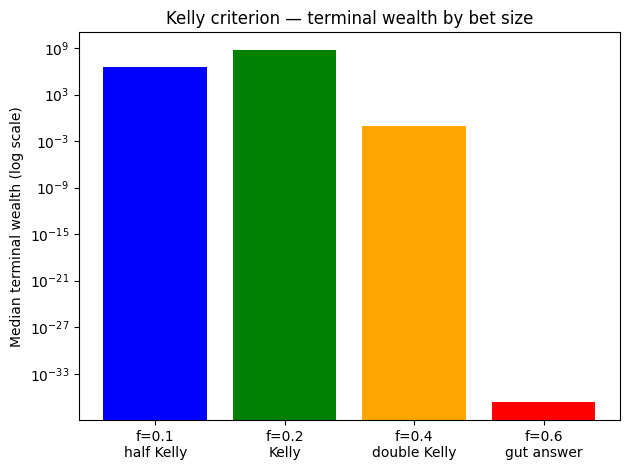

In [ ]:
import numpy as np
wealth = np.zeros((10000,4))
f = [0.1, 0.2, 0.4, 0.6]
for j in range(10000):
    df = (np.random.rand(1000)<0.6)
    for index, value in enumerate(f):
        wealth[j][index] = 1 * (1+value)**(np.sum(df)) * (1-value)**(1000 - np.sum(df))
medians = np.median(wealth, axis=0)
f_values = [0.1, 0.2, 0.4, 0.6]
labels = ['f=0.1\nhalf Kelly', 'f=0.2\nKelly', 'f=0.4\ndouble Kelly', 'f=0.6\ngut answer']
colors = ['blue', 'green', 'orange', 'red']

fig, ax = plt.subplots()
ax.bar(labels, medians, color=colors)
ax.set_yscale('log')
ax.set_ylabel('Median terminal wealth (log scale)')
ax.set_title('Kelly criterion — terminal wealth by bet size')
plt.tight_layout()
plt.savefig('kelly_simulation.png', dpi=300)
plt.show()



 mean = 0.0011384512734693257; std = 0.00977755116084672; kurtosis = -0.23459161458242273; skewness = 0.07281788854906564


[*********************100%***********************]  1 of 1 completed

 mean = 0.000497776285764801; std = 0.010267498971866506; kurtosis = 18.32946423064044; skewness = -1.0195885786499208


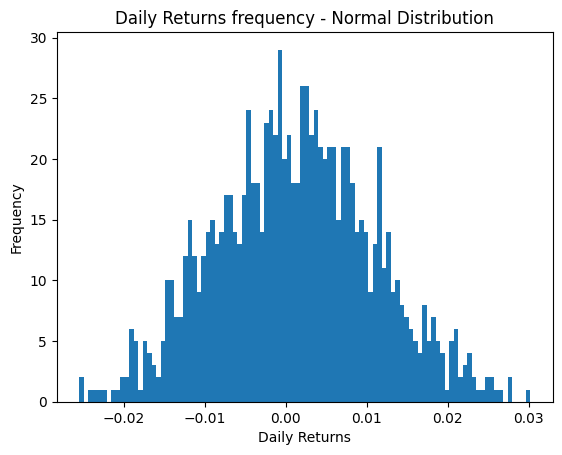

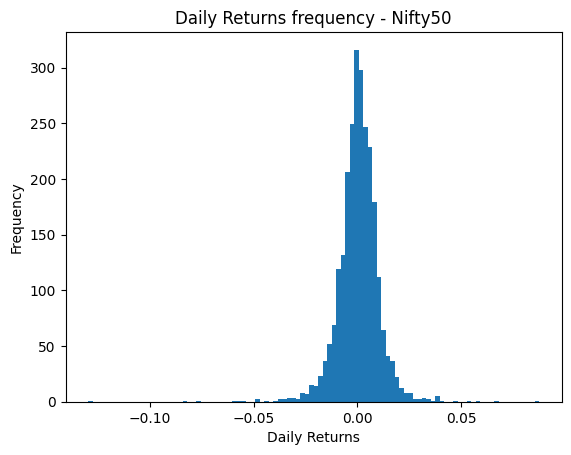

In [ ]:
import numpy as np
df = pd.Series(np.random.normal(loc = 0.001, scale=0.01, size=(1000)))
print(f" mean = {df.mean()}; std = {df.std()}; kurtosis = {df.kurt()}; skewness = {df.skew()}")


df_nifty = yf.download("^NSEI", start="2016-01-01")
df_nifty.columns = df_nifty.columns.droplevel(level=1)
df_nifty.columns
df_nifty['daily_returns'] = df_nifty['Close'].pct_change()
print(f" mean = {df_nifty['daily_returns'].mean()}; std = {df_nifty['daily_returns'].std()}; kurtosis = {df_nifty['daily_returns'].kurt()}; skewness = {df_nifty['daily_returns'].skew()}")

plt.hist(df, bins= 100)
plt.ylabel("Frequency")
plt.xlabel("Daily Returns")
plt.title("Daily Returns frequency - Normal Distribution")
plt.show()
    
plt.hist(df_nifty['daily_returns'], bins= 100)
plt.ylabel("Frequency")
plt.xlabel("Daily Returns")
plt.title("Daily Returns frequency - Nifty50")
plt.show()

In [ ]:
count = 0
for i in range(100000):
    df = np.random.randint(low=1,high=366,size=40)
    df.sort()
    for j in range(1, 40):
        if df[j]== df[j-1]:
            count+=1
            break
print(count/100000)

df = np.arange(365, 325, -1)
print(1-(np.prod(df.astype(float))/(365**40)))

0.89203
0.891231809817949


In [ ]:
import numpy as np
dp = np.zeros(100000)
for i in range(100000):
    count=1
    while np.random.randint(2)==1:
        count += 1
    dp[i] = 2**count
ex = dp.mean()
print(ex)

18.05002


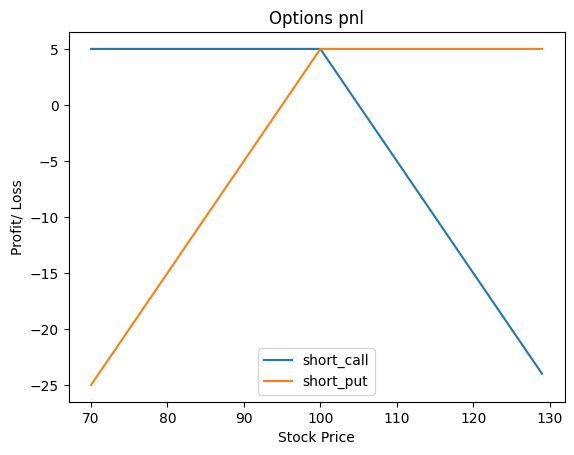

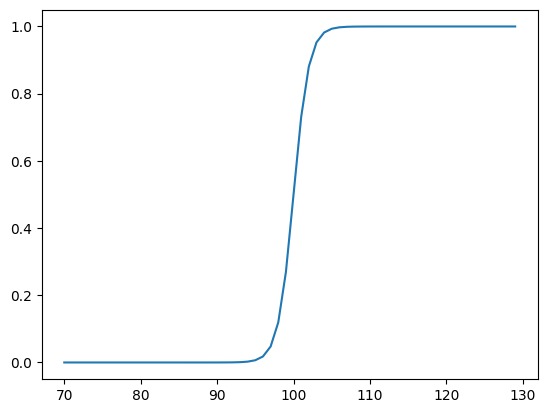

In [ ]:
import numpy as np
premium = 5
strike = 100
prices  = np.arange(70, 130)
long_call = np.where(prices-100<0, -5, prices - 105)
long_put = np.where(prices-100>0, -5, 95 - prices)
short_call = np.where(prices-100<0, 5,  105 - prices)
short_put = np.where(prices-100>0, 5, prices - 95)
delta_long_call = 1/(1+np.exp(strike - prices))
# plt.plot(prices, long_call, label='long_call')
# plt.plot(prices, long_put, label='long_put')
plt.plot(prices, short_call, label='short_call')
plt.plot(prices, short_put, label='short_put')
plt.title('Options pnl')
plt.xlabel('Stock Price')
plt.ylabel('Profit/ Loss')
plt.legend()
plt.show()
plt.plot(prices, delta_long_call)


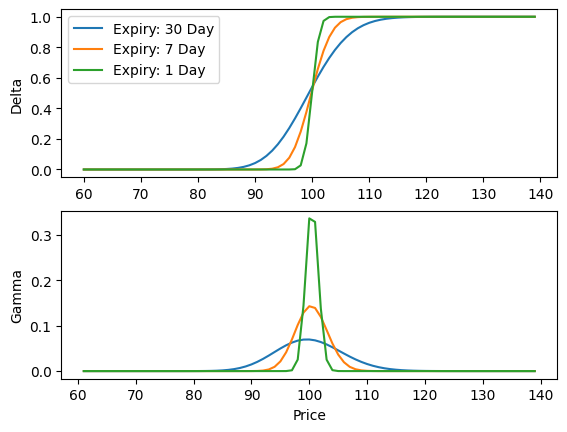

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
K = 100 # strike price
S  = np.arange(60, 140) #stock price
r = 0.05 #risk free rate
v = 0.20 # Implied volatility
T1 = 0.083 # Time 1 months
T2 = 0.0192 # Time 7 Day
T3 = 0.0027 # Time 1 Day
d1 = (np.log(S/K) + (r + v**2/2) * T1)/(v*T1**0.5)
d2 = (np.log(S/K) + (r + v**2/2) * T2)/(v*T2**0.5)
d3 = (np.log(S/K) + (r + v**2/2) * T3)/(v*T3**0.5)
delta1 = norm.cdf(d1)
delta2 = norm.cdf(d2)
delta3 = norm.cdf(d3)
gamma1 = np.diff(delta1)
gamma2 = np.diff(delta2)
gamma3 = np.diff(delta3)
fig, ax = plt.subplots(2,1)
ax[0].plot(S, delta1, label='Expiry: 30 Day')
ax[0].plot(S, delta2, label='Expiry: 7 Day')
ax[0].plot(S, delta3, label='Expiry: 1 Day')


ax[1].plot(S[1:], gamma1,label='Expiry: 30 Day')
ax[1].plot(S[1:], gamma2,label='Expiry: 7 Day')
ax[1].plot(S[1:], gamma3,label='Expiry: 1 Day')

ax[0].set_ylabel('Delta')
ax[1].set_ylabel('Gamma')
ax[1].set_xlabel('Price')

ax[0].legend()

Away from the strike, gamma risk decreases as the expiry approaches at the money. Gamma risk increases as the expiry approaches.

Text(0.5, 0, 'Price')

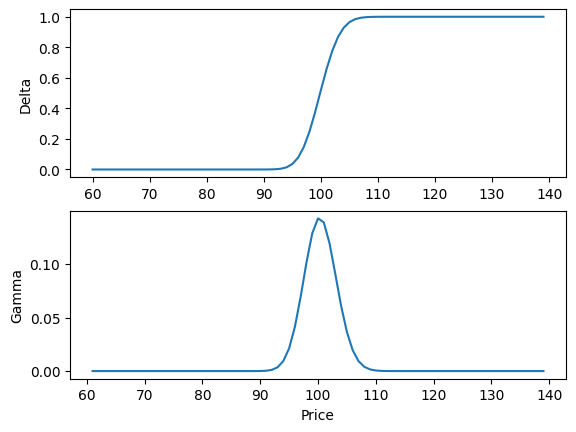

In [ ]:
K = 100 # strike price
S  = np.arange(60, 140) #stock price
r = 0.05 #risk free rate
v = 0.20 # Implied volatility
T = 0.0192 # Time 7 Day
d1 = (np.log(S/K) + (r + v**2/2) * T)/(v*T**0.5)
delta = norm.cdf(d1)
gamma = np.diff(delta)
fig, ax = plt.subplots(2,1)
ax[0].plot(S, delta)
ax[1].plot(S[1:], gamma)
ax[0].set_ylabel('Delta')
ax[1].set_ylabel('Gamma')
ax[1].set_xlabel('Price')

Text(0.5, 0, 'Price')

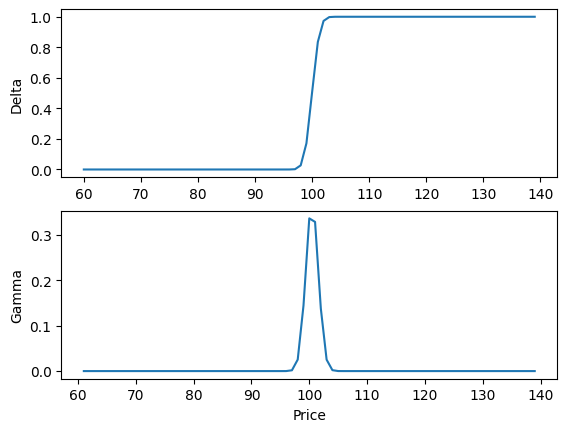

In [ ]:
import numpy as np
from scipy.stats import norm
K = 100 # strike price
S  = np.arange(60, 140) #stock price
r = 0.05 #risk free rate
v = 0.20 # Implied volatility
T = 0.0027 # Time 1 Day
d1 = (np.log(S/K) + (r + v**2/2) * T)/(v*T**0.5)
delta = norm.cdf(d1)
gamma = np.diff(delta)
fig, ax = plt.subplots(2,1)
ax[0].plot(S, delta)
ax[1].plot(S[1:], gamma)
ax[0].set_ylabel('Delta')
ax[1].set_ylabel('Gamma')
ax[1].set_xlabel('Price')

In [10]:
import numpy as np
strike = np.arange(60,140)
stock = 100
implied_volatility = np.where(strike>stock, 0.000025 * (strike - stock)**2 + 0.20,0.00003 * (strike - stock)**2 + 0.20)


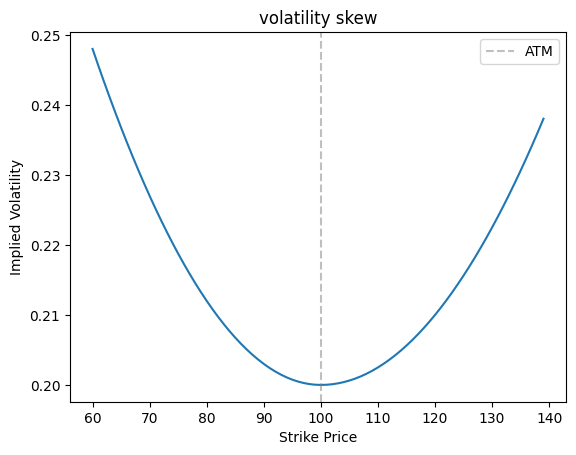

In [13]:
plt.plot(strike, implied_volatility)
plt.title('volatility skew')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.axvline(x=100, linestyle='--', color='grey', alpha=0.5, label='ATM')
plt.legend()